# HTG overview

The Hierarchal Tensor Graph (HTG) is the core object where the Earth System Model (ESM)
is encoded and specified. The HTG provides the information needed to build a CREST
model using the Tensor Network backend. As the name suggest, HTG is a hierarchal graph object,
and as such, nodes within a HTG are HTGs themselves.


In [1]:
# import crest
%cd -q ..
from crest import HierarchalTensorGraph

/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <1.29.0 is required for this version of SciPy (detected version 1.22.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


## HTG basenodes

It has 2 modes:

1.	A single node graph, referred to as a basenode, that represents a fundamental physical
    process in an ESM. The basenode is the main object intended for specifying an actual model
    of a physical process. As such, you must supply a callable function when instantiating a basenode.

2.	A multi-node graph (nodes>1) used to represent ESM sub-systems. In this mode, HTG is not
    instantiated with callable function. Instead, nodes and edges are added to create a sub-system.
    Nodes can either be fundamental processes (basenode) or sub-systems (multi-node HTGs).

#### A single node graph

In [2]:
# A simple basenode that squares a number
process = lambda X : {'square' : X['x']*X['x']}
sq = HierarchalTensorGraph(node=process)

In [3]:
# All HTGs must have a name. If no name is specified, HTG will try standard naming variables
sq.name

'<lambda>'

In [4]:
# Best to always name them if what you want during construction
# sq = HierarchalTensorGraph(node=process,name='square') 
# or simply
sq.name = 'square'

In [5]:
# Every node contains a graph object that includes the nodes and edges within it. 
# A basenode has an 'empty' graph.
# By design, you can never add nodes to a basenode.
if sq.is_empty:
    print(f'{sq.name} has an empty graph!')

square has an empty graph!


In [6]:
# Let's execute the HTG by creating the input dict
X = {'x' : 2}
sq(X)

{'square': 4}

#### Multi-node HTGs

Mutlinode HTG are used to represent coupled systems. Nodes in this mode can either
be basenodes or other multinode HTGs.

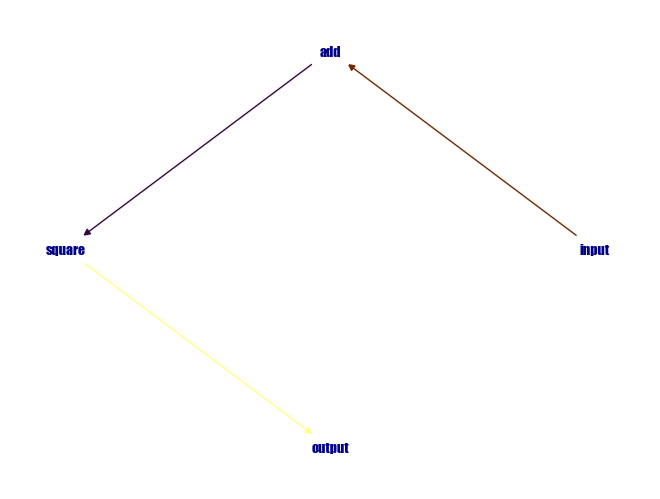

In [7]:
# Let's now create a HTG with multiple nodes to create a graph for a*(b_c)
process = lambda X : {'sum' : X['x_1'] + X['x_2']}     
add = HierarchalTensorGraph(node=process,name='add')    
add_square = HierarchalTensorGraph(name='add_square') # Only the name needs to be given

# Specify the graph
add_square.add_edge('input',add)                       
add_square.add_edge(sq,'output')
add_square.add_edge(add,sq)
add_square.draw()

In [8]:
# Accessing nodes with __getitem__
f'__getitem__ = {add_square["add"]}'

'__getitem__ = HierarchalTensorGraph("add", id=6172406784)'

In [9]:
# Get a dictionary of the nodes in the HTG
add_square.nodes

{'input': HierarchalTensorGraph("input", id=6172405392),
 'add': HierarchalTensorGraph("add", id=6172406784),
 'square': HierarchalTensorGraph("square", id=6172403328),
 'output': HierarchalTensorGraph("output", id=6172407312)}

## Renaming I/O in HTGs 

It will often be necessary to rename I/O in the graphs to match
the naming conventions used by the nodes in your graph.

In [10]:
# It's a best practice to set the the names of input/output tensors.
# A HTG will use this information to try and find and select the input
# it needs. Note: you can do this at construction time as well by passing
# inputs={} and outputs={}

add_square['add'].inputs = {'x_1' : None, 'x_2' : None}
add_square['add'].outputs= {'sum' : None} #leave the output as y
add_square['square'].inputs = {'x' : None}
add_square['square'].outputs = {'square' : None} #leave the output as y

In [11]:
# We have to rename the output of the addition node
# from y to x in order to match the input of the square node
# You can rename any incoming inputs or outgoing outputs
# using renami_io.

add_square.rename_io(outputs_map={'sum' : 'x'}, node='add')

In [12]:
X = {'x_1' : 5, 'x_2' : 3}
add_square(X)

{'square': {'square': 64}}

In [13]:
# Notice we get a nested dict for output because
# HTG prepends the nodename to ensure unique names
# in the graph. To fix this, as recommended, we simply
# set the inputs/outputs of add_square.

add_square.inputs = {'x_1' : None, 'x_2' : None}
add_square.outputs = {'square' : None} # this is the only needed to fix the output

In [14]:
# Let's check that other input keys are ignored.
X = {'x_1' : 5, 'x_2' : 3, 'z' : 12}
add_square(X)

{'square': 64}

In [15]:
# Sometimes we may want to wrap our HTG in a class for more flexibility
class AddSquare(HierarchalTensorGraph):
    
    def __init__(self,name='add_square'):
        # Construct a multinode HTG and specify I/O
        super().__init__(name=name,
                         inputs = {'x_1' : None, 'x_2' : None},
                         outputs = {'add_square' : None}
        )
        
        # Create an add basenode and specify I/O
        add = HierarchalTensorGraph(
            lambda X : {'sum' : X['x_1'] + X['x_2']},
            inputs = {'x_1' : None, 'x_2' : None},
            outputs = {'sum' : None},
            name = 'add'
        )
        
        # Create a square basenode and specify I/O
        square = HierarchalTensorGraph(
            lambda X : {'square' : X['x']*X['x']},
            inputs = {'x' : None},
            outputs = {'square' : None},
            name = 'square'
        )
            
        # Create the graph    
        self.add_edge('input',add)
        self.add_edge(add,square)
        self.add_edge(square,'output')
        
        # Don't forget to rename the output of add
        self.rename_io(outputs_map={'sum' : 'x'}, node='add')
        
        # And of square since we specified add_square for the output
        self.rename_io(outputs_map={'square' : 'add_square'}, node=square)

In [16]:
# Evaluate our class
X = {'x_1' : 5, 'x_2' : 3, 'z' : 12}
add_sq = AddSquare()
add_sq(X)

{'add_square': 64}

## An HTG with one more layer

Here, we will add another layer to do log(a*(b+c))

In [17]:
# let's create another layer of the hierarchy.
from math import log

class LogAddSquare(HierarchalTensorGraph):
        
    def __init__(self,name='log_add_square'):
        super().__init__(
            name=name,
            inputs = {'x_1' : None, 'x_2' : None},
            outputs = {name : None}
        )
        
        # Create log basenode
        lg = HierarchalTensorGraph(
            name = 'log',
            node = lambda X : {'log' : log(X['x'])},
            inputs = {'x' : None},
            outputs = {'log' : None}
        )
        
        # Create graph
        self.add_edge('input',AddSquare())
        self.add_edge('add_square',lg)
        self.add_edge('log','output')
        self.add_edge('add_square','output')
        # Rename log add_square output to match log input
        self.rename_io(outputs_map={'add_square' : 'x'}, node='add_square')

        # Rename log output to match output of LogAddSquare
        self.rename_io(outputs_map={'log' : 'log_add_square'}, node='log')

In [18]:
# Execute the HTG
las = LogAddSquare()
las(X)

{'log_add_square': 4.1588830833596715}

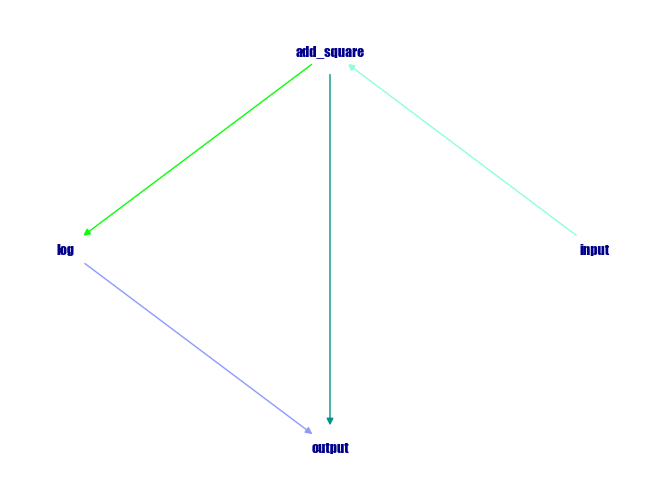

In [19]:
# Draw the HTG
las.draw()

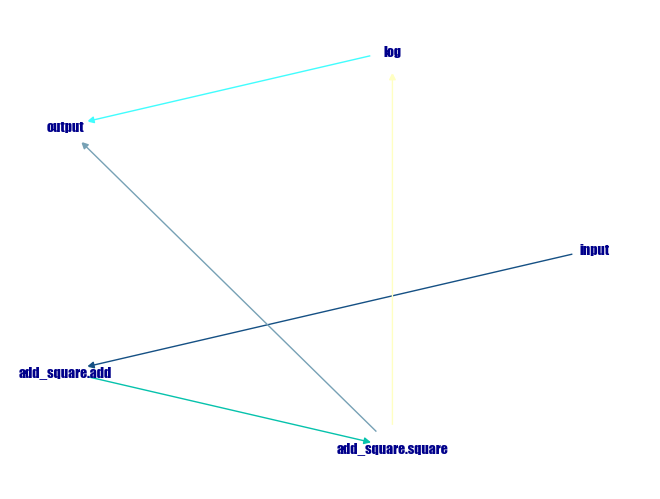

In [20]:
# Draw the HTG with add_square 'expanded'
las.draw(expand_nodes='add_square')

In [21]:
# List its nodes
las.nodes

{'input': HierarchalTensorGraph("input", id=6174156848),
 'add_square': HierarchalTensorGraph("add_square", id=6173846080),
 'log': HierarchalTensorGraph("log", id=6173845120),
 'output': HierarchalTensorGraph("output", id=6174152048)}

In [22]:
# List ALL nodes within the whole system
# Note: tuples are used to specify nodes uniquely
# that are deeper in the graph
las.all_nodes

{('input',): HierarchalTensorGraph("input", id=6174156848),
 ('add_square',): HierarchalTensorGraph("add_square", id=6173846080),
 ('add_square', 'input'): HierarchalTensorGraph("input", id=6174154352),
 ('add_square', 'add'): HierarchalTensorGraph("add", id=4421478832),
 ('add_square', 'square'): HierarchalTensorGraph("square", id=6172405776),
 ('add_square', 'output'): HierarchalTensorGraph("output", id=6174161696),
 ('log',): HierarchalTensorGraph("log", id=6173845120),
 ('output',): HierarchalTensorGraph("output", id=6174152048)}

In [23]:
# We can access nodes of the parent simply with their names
las['log']

HierarchalTensorGraph("log", id=6173845120)

In [24]:
# We could also give the name as a tuple
las[('log')]

HierarchalTensorGraph("log", id=6173845120)

In [25]:
# If we want to access nodesdeeper within the HTG, we MUST use a tuple
las[('add_square','add')]

HierarchalTensorGraph("add", id=4421478832)

In [26]:
# Iterate through ALL nodes in a HTG
for i in las:
    print(i)

[('input',), HierarchalTensorGraph("input", id=6174156848)]
[('add_square',), HierarchalTensorGraph("add_square", id=6173846080)]
[('add_square', 'input'), HierarchalTensorGraph("input", id=6174154352)]
[('add_square', 'add'), HierarchalTensorGraph("add", id=4421478832)]
[('add_square', 'square'), HierarchalTensorGraph("square", id=6172405776)]
[('add_square', 'output'), HierarchalTensorGraph("output", id=6174161696)]
[('log',), HierarchalTensorGraph("log", id=6173845120)]
[('output',), HierarchalTensorGraph("output", id=6174152048)]


In [27]:
# Ask if a node is in a HTG
print([
    'log' in las, 
    ('log') in las, 
    ('add_square','add') in las,
    'add' in las]
)

[True, True, True, False]


In [28]:
# Access to individual node output. Every node stores
# the output of the most recent call which can be accessed as
print([las['log'].output,las[('add_square','add')].output])

[{'log': 4.1588830833596715}, {'sum': 8}]


In [29]:
las.print_edge_labels(expand_nodes='all')

,source,target,source output,target inputs,valid
0,input,add_square.add,"['x_1', 'x_2']","['x_1', 'x_2']",True
1,log,output,"['x', 'log_add_square']",['log_add_square'],True
2,add_square.add,add_square.square,['x'],['x'],True
3,add_square.square,log,['x'],['x'],True
4,add_square.square,output,['x'],['log_add_square'],True
